# COGS 108 - EDA Checkpoint

## Authors
- Jing Wang: Conceptualization, Project administration, EDA framework design, Interpretation, Writing – review & editing, Final integration.
- Qifeng Shen: Data curation, Software, Data wrangling, Missingness analysis, Outlier treatment, Writing – original draft (Data cleaning section).
- Ivy Wu: Analysis, Visualization, Exploratory data analysis (univariate & bivariate), Software.
- Yuqian Gao: Analysis, Methodology, Statistical exploration, Correlation analysis, Modeling rationale, Writing – original draft (Analysis logic section).
- Alina Gao: Ethics & Privacy (updated), Bias analysis in EDA, Societal context interpretation, Writing – original draft (Ethics & Interpretation sections), Writing – review & editing.


# Research Question

What listing characteristics are associated with nightly prices of Airbnb rentals in San Diego?
- Using publicly available Airbnb listing data, we examine how capacity (accommodates/bedrooms/bathrooms), property type/room type, neighborhood or zip code, review ratings, minimum nights, and availability relate to nightly price. We estimate these associations using multiple regression (e.g., log(price)) while controlling for host experience (host listings count/superhot status), amenity indicators (Wi-Fi, parking, pool, kitchen, AC), booking policies (instant book, cancellation policy), and time-related factors (month/season) when available.


## Background and Prior Work

Airbnb has become a major platform in the short-term rental market and plays an important role in tourism and local housing economies. Nightly pricing is a key factor that affects both hosts and guests, as it influences host revenue and guest booking decisions. However, Airbnb prices are not set randomly and are often related to various listing characteristics.
Prior research has examined determinants of Airbnb pricing using publicly available listing data. For example, Wang and Nicolau (2017) found that location, property type, and review ratings significantly influence nightly prices. Similarly, Gunter (2018) showed that listings offering entire homes, larger accommodation capacity, and higher guest ratings tend to command higher prices. These studies suggest that observable characteristics such as neighborhood, property size, availability, and user-generated reviews are important predictors of rental pricing. While prior studies have examined European or multi-country markets, fewer studies focus specifically on San Diego, which motivates our city-level analysis
Building on this prior work, our project focuses on modeling Airbnb rental prices in San Diego. Specifically, we examine how listing characteristics such as location (e.g., zip code), property type (entire home vs. private room), accommodation capacity, availability, and guest review ratings jointly relate to nightly prices. We apply exploratory data analysis and regression-based modeling to estimate the relative importance of these features.
At the same time, we acknowledge that our dataset is observational and may omit unobserved factors, such as host experience, interior design quality, off-platform negotiations, or seasonal events (e.g., conventions or tourism peaks) that could also affect pricing. Therefore, our results should be interpreted as associations rather than causal effects. Our city-level analysis allows us to examine pricing patterns within a single metropolitan area while contributing to the broader literature on short-term rental pricing.

### References
- Wang, D., & Nicolau, J. L. (2017). Price determinants of sharing economy-based accommodation rental: A study of Airbnb listings. International Journal of Hospitality Management, 62, 120–131.
- Gunter, U. (2018). What makes an Airbnb listing attractive? Evidence from Europe. Tourism Economics, 24(2), 210–225.


# Hypothesis


We hypothesize that Airbnb rental prices in San Diego are associated with several characteristics, including location, size, and available services or amenities. Listings located closer to scenic areas such as the coast or forests, or city centers, are expected to be associated with higher nightly prices. These locations typically offer greater convenience and a more desirable stay experience. In addition, larger listings and those offering more amenities or higher quality service, such as pet-friendly options, may be associated with higher prices due to higher maintenance costs.

Our analysis plan begins with exploratory data analysis (EDA) to examine the distributions of rental prices and the above listing characteristics. We will use visualizations to explore how prices vary across different locations and feature categories and then apply regression models to assess the associations between rental prices and these characteristics while controlling for other relevant variables. Throughout the analysis, we will clearly state assumptions and discuss potential limitations, such as unobserved factors like:

Interior design and quality: Listings that are well-decorated or recently renovated may command higher prices, even when their square footage is similar to other listings.

Host communication style: Hosts who respond quickly and are polite and patient with guests may increase perceived value and allow hosts to charge higher prices.

Off-platform negotiations: Some hosts may offer discounts or special rates outside of Airbnb's platform, meaning the actual transaction price may differ from the listed price in our dataset.

Subjective perceptions of neighborhood safety: Guests’ perceptions of safety may influence willingness to pay.

Proximity to major seasonal events: Large events in San Diego, such as Comic-Con, the San Diego Marathon, and the MLB season, may temporarily raise local demand and rental prices in ways that are not fully reflected in broad time variables.

## Data


### Data overview

To examine which listing characteristics are associated with Airbnb nightly prices in San Diego, we use two complementary datasets:
(1) Listing-level Airbnb dataset containing property, host, and review-related attributes.
(2) County-level socioeconomic indicator from the U.S. Census Bureau (ACS) providing broader economic context.

---

#### Dataset #1: Airbnb Listings Data (San Diego)

**Dataset name:** Airbnb Listings Data (San Diego)  

**Source:** `data/00-raw/listings.csv` (public Airbnb listing data)

**Unit of analysis:** One row = one Airbnb listing; one column = one listing-level attribute (tidy format)  

**Size:** 13,162 listings × 18 variables (raw data)

**Primary outcome variable:** `nightly_price` (USD per night) 
- represents the advertised platform price (may differ from final transaction price).

**Core predictors for this analysis:**

- **Room characteristics:** `room_type`

- **Location:** `neighbourhood`, `latitude`, `longitude`

- **Booking constraints:** `minimum_nights`

- **Review activity:** `number_of_reviews`, `last_review`

- **Availability indicator:** `availability_365`

**Notes on missingness and limitations:**

- Some fields contain systematic missing values (e.g., `last_review` is missing for listings with zero reviews).

- The original amenities column is missing in this dataset; thus, amenities are not included in this checkpoint analysis.

- The dataset includes only listings visible on Airbnb; findings describe associations, not causal effects.

- Nightly prices are highly right-skewed; we remove extreme outliers using the IQR method (Q3 + 1.5 * IQR).



#### Dataset #2: American Community Survey (ACS) Income (San Diego County)

**Dataset name:** ACS Table S1901 (Income in the Past 12 Months)  

**Source:** U.S. Census Bureau, ACS 1-Year Estimates (2024) via `data/00-raw/ACSST1Y2024.S1901.csv`

**Geographic level:** County (San Diego County, CA)  

**Variable used:** Median household income (USD)

This dataset provides a county-level socioeconomic benchmark for San Diego. Because it is measured at the county level, it is used for context only and not merged with individual listings.

**Limitations:**  
ACS estimates are survey-based, subject to sampling variability, and coarse-grained (cannot capture within-county neighborhood variation).

In [1]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd

listings = pd.read_csv("data/00-raw/listings.csv", low_memory=False)

# Missing last_review summary
missing_summary = listings['last_review'].isna().groupby(listings['last_review'].isna()).count()
print("Missing last_review summary:")
print(missing_summary)

Missing last_review summary:
last_review
False    10962
True      2200
Name: last_review, dtype: int64


In [3]:
listings.shape
print("Shape of listings dataframe:", listings.shape)

Shape of listings dataframe: (13162, 18)


In [4]:
print("Columns in listings dataframe:")
print(listings.columns.tolist())

Columns in listings dataframe:
['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm', 'license']


In [5]:
listings.isna().sum()
print("Missing values in each column:")
print(listings.isna().sum())

Missing values in each column:
id                                    0
name                                  0
host_id                               0
host_name                            33
neighbourhood_group               13162
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                              1781
minimum_nights                        0
number_of_reviews                     0
last_review                        2200
reviews_per_month                  2200
calculated_host_listings_count        0
availability_365                      0
number_of_reviews_ltm                 0
license                            2849
dtype: int64


In [6]:
listings['price'].describe()
print("Price column summary:")
print(listings['price'].describe())

Price column summary:
count    11381.000000
mean       650.378526
std       4131.343694
min         11.000000
25%        115.000000
50%        176.000000
75%        300.000000
max      50040.000000
Name: price, dtype: float64


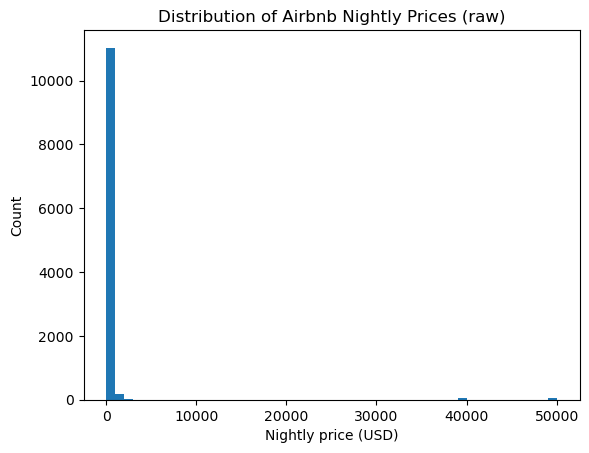

In [7]:
import matplotlib.pyplot as plt

# clean nightly_price -> numeric
price_num = (
    listings["price"]
    .astype(str)
    .str.replace(r"[\$,]", "", regex=True)
)
price_num = pd.to_numeric(price_num, errors="coerce")

plt.hist(price_num.dropna(), bins=50)
plt.title("Distribution of Airbnb Nightly Prices (raw)")
plt.xlabel("Nightly price (USD)")
plt.ylabel("Count")
plt.show()

In [8]:
import sys
sys.path.append('./modules')
import os

data_path = 'data/00-raw/listings.csv'
if os.path.exists(data_path):
    print("Data already exists, skipping download.")
else:
    print(f"{data_path} not found. Please add it manually.")

Data already exists, skipping download.


### Dataset #1: Airbnb Listings Data (San Diego)

This dataset contains publicly available information about Airbnb listings in San Diego. Each row corresponds to one listing, and each column represents a listing-level attribute (tidy format). The dataset includes **13,162 listings × 18 variables**, covering listing characteristics, review activity, host information, and geographic attributes.



#### Key Metrics and Units

- **Nightly price (`nightly_price`)**:  
  Measured in USD per night. This represents the advertised platform price and may differ from the final transaction price due to discounts or seasonal adjustments. Extremely high values are treated as right-tail outliers during data cleaning.

- **Room characteristics:**  
  - `room_type` (categorical variable indicating listing type, e.g., Entire home/apt, Private room)

- **Location variables:**  
  - `neighbourhood` (categorical neighborhood label)  
  - `latitude`, `longitude` (geographic coordinates)

- **Booking constraints:**  
  - `minimum_nights` (number of nights required per booking)

- **Review activity:**  
  - `number_of_reviews` (count of total reviews)  
  - `last_review` (date of most recent review)

- **Availability indicator:**  
  - `availability_365` (number of days available in the next 365 days)


#### Missingness and Limitations

Some variables contain systematic missing values. For example, `last_review` is missing for listings with zero reviews. This reflects platform mechanics rather than random data loss.

The dataset includes only listings visible on Airbnb and does not represent the entire rental market in San Diego. As this is observational data, results should be interpreted as associations rather than causal conclusions.


#### Concerns / Potential Bias

- The dataset may be biased toward listings that remain active or receive reviews.
- Posted prices may differ from final transaction prices.
- Neighborhood labels may not perfectly reflect economic or zoning boundaries.



#### Purpose of This Section

In the following steps, we load the raw dataset, inspect its structure, evaluate missingness, address right-skewed price outliers using a percentile-based approach, and prepare a cleaned dataset for further exploratory analysis and modeling.

### Data Wrangling – Airbnb Listings (San Diego 2025)

This section focuses on cleaning and preparing the Airbnb listings dataset for analysis and modeling. We restrict our analysis to variables that are present in the raw dataset and relevant to pricing behavior.

**Target variable:**  
- `nightly_price` (USD per night)

**Predictor variables used in this checkpoint:**
- `room_type` (categorical listing type)
- `neighbourhood` (location label)
- `latitude`, `longitude` (geographic coordinates)
- `minimum_nights` (minimum stay requirement)
- `number_of_reviews` (total review count)
- `availability_365` (number of days available in the next 365 days)

During wrangling, we:

- Convert the price variable to numeric format and remove invalid values  
- Examine and document systematic missingness (e.g., `last_review`)  
- Address extreme right-skewed prices using a percentile-based outlier filter  
- Standardize variable formats where necessary  
- Save a cleaned dataset to `data/02-processed/` for reproducibility  

The goal of this stage is to produce a transparent, reproducible dataset suitable for exploratory analysis and statistical modeling.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load raw dataset
listings = pd.read_csv("data/00-raw/listings.csv", low_memory=False)
print("All columns in raw dataset:")
print(listings.columns.tolist())

# Keep only columns that exist
cols_wanted = [
    "nightly_price",
    "room_type",
    "neighbourhood",
    "zipcode",
    "latitude",
    "longitude",
    "accommodates",
    "property_type",
    "minimum_nights",
    "maximum_nights",
    "number_of_reviews",
    "review_scores_rating",
    "amenities",
    "last_review",
]
cols_keep = [c for c in cols_wanted if c in listings.columns]
df = listings[cols_keep].copy()

print("Columns kept for analysis:")
print(df.columns.tolist())
print("Shape:", df.shape)

All columns in raw dataset:
['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm', 'license']
Columns kept for analysis:
['room_type', 'neighbourhood', 'latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'last_review']
Shape: (13162, 7)


In [10]:
if 'price' in listings.columns:
    df['nightly_price'] = (
        listings['price'].astype(str)
        .str.replace(r'[\$,]', '', regex=True)
    )
    df['nightly_price'] = pd.to_numeric(df['nightly_price'], errors='coerce')
    df = df.dropna(subset=['nightly_price'])
    df = df[df['nightly_price'] > 0]
    print("After cleaning price, dataset shape:", df.shape)
else:
    raise KeyError("No price column found in CSV. Check your column names with listings.columns")

After cleaning price, dataset shape: (11381, 8)


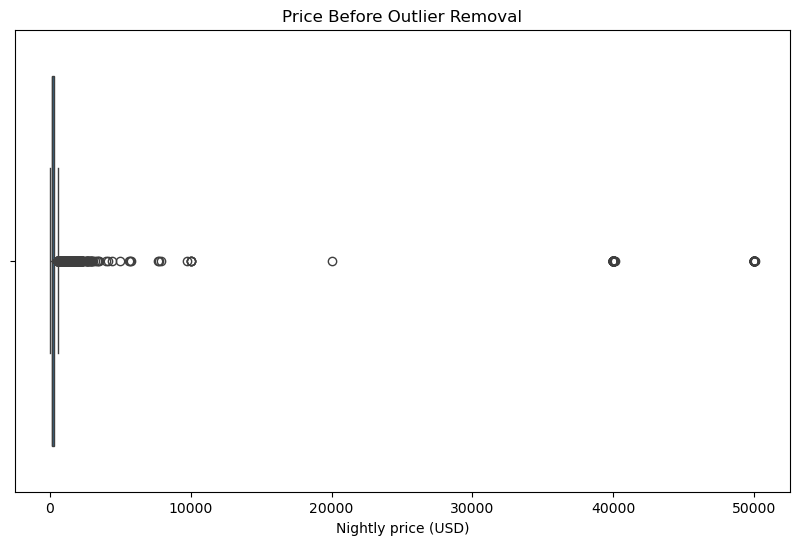

In [11]:
if 'nightly_price' in df.columns:
    plt.figure(figsize=(10,6))
    sns.boxplot(x=df['nightly_price'])
    plt.title("Price Before Outlier Removal")
    plt.xlabel("Nightly price (USD)")
    plt.show()

In [12]:
Q1 = df['nightly_price'].quantile(0.25)
Q3 = df['nightly_price'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = df['nightly_price'].quantile(0.99)
df = df[df['nightly_price'] <= upper_bound]
print("IQR method upper bound for nightly_price:", upper_bound)
print("Note: Lower bound not applied since prices cannot be negative.")

df = df[df['nightly_price'] <= upper_bound]
print("Dataset shape after outlier removal:", df.shape)

IQR method upper bound for nightly_price: 4023.0000000000837
Note: Lower bound not applied since prices cannot be negative.
Dataset shape after outlier removal: (11267, 8)


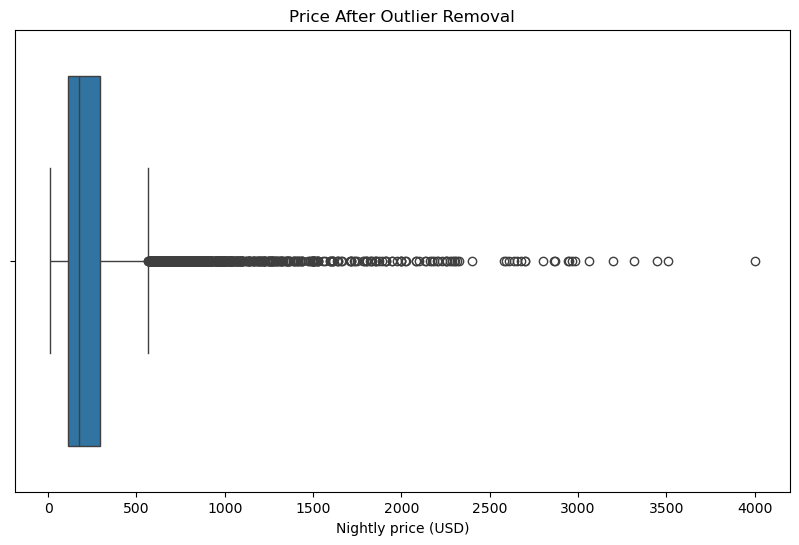

In [13]:
plt.figure(figsize=(10,6))
sns.boxplot(x=df['nightly_price'])
plt.title("Price After Outlier Removal")
plt.xlabel("Nightly price (USD)")
plt.show()

In [14]:
amenity_list = ['Wifi', 'Pool', 'Parking', 'Kitchen', 'Air conditioning']

if 'amenities' in df.columns:
    for amenity in amenity_list:
        col_name = amenity.lower().replace(' ', '_')
        df[col_name] = df['amenities'].str.contains(amenity, case=False, na=False).astype(int)

    print("Sum of binary amenities columns:\n", df[['wifi', 'pool', 'parking', 'kitchen', 'air_conditioning']].sum())
    print("\nSample amenities column:\n", df['amenities'].head(3))
    print("Dataset shape after adding amenities:", df.shape)
else:
    print("No 'amenities' column in this CSV. Skipping amenities processing.")
    print(df.columns.tolist())

No 'amenities' column in this CSV. Skipping amenities processing.
['room_type', 'neighbourhood', 'latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'last_review', 'nightly_price']


In [15]:
import os
os.makedirs("data/02-processed", exist_ok=True)

df.to_csv("data/02-processed/listings_clean.csv", index=False)
print("Processed dataset saved to data/02-processed/listings_clean.csv")

Processed dataset saved to data/02-processed/listings_clean.csv


#### Dataset #2: American Community Survey (ACS) Income (San Diego County)

This dataset comes from the U.S. Census Bureau’s American Community Survey (ACS), Table S1901: *Income in the Past 12 Months*. We extract the **median household income** for San Diego County, California.

**Source:** U.S. Census Bureau, ACS 1-Year Estimates (2024)  
**Geographic level:** County (San Diego County, CA)  
**Variable used:** Median household income (USD)  
**Extraction logic:** Value from the row *“Median income (dollars)”* under the column corresponding to *San Diego County, California – Households!!Estimate*

This dataset provides county-level socioeconomic context for Airbnb listings in San Diego. The median household income serves as a macroeconomic benchmark for understanding the broader economic environment in which short-term rentals operate.

Because this variable is measured at the county level, it is not merged at the listing or ZIP-code level in this checkpoint. Instead, it is used to contextualize findings from the listing-level analysis.

**Limitations:**  
ACS estimates are survey-based and subject to sampling variability. County-level measures are coarse and do not capture within-county neighborhood variation.

In [16]:
import pandas as pd
import os

census_file = "data/00-raw/ACSST1Y2024.S1901-2026-02-19T053324.csv"

# Check if file exists
if not os.path.exists(census_file):
    raise FileNotFoundError(f"File not found: {census_file}")

# Load CSV
census_raw = pd.read_csv(census_file, low_memory=False)

# Overview of dataset
print("ACS raw dataset shape:", census_raw.shape)
print("\nColumns in CSV:")
print(census_raw.columns.tolist())

print("\nFirst 5 rows of the dataset:")
print(census_raw.head())

ACS raw dataset shape: (17, 9)

Columns in CSV:
['Label (Grouping)', 'San Diego County, California!!Households!!Estimate', 'San Diego County, California!!Households!!Margin of Error', 'San Diego County, California!!Families!!Estimate', 'San Diego County, California!!Families!!Margin of Error', 'San Diego County, California!!Married-couple families!!Estimate', 'San Diego County, California!!Married-couple families!!Margin of Error', 'San Diego County, California!!Nonfamily households!!Estimate', 'San Diego County, California!!Nonfamily households!!Margin of Error']

First 5 rows of the dataset:
         Label (Grouping) San Diego County, California!!Households!!Estimate  \
0                   Total                                          1,185,092   
1       Less than $10,000                                               3.9%   
2      $10,000 to $14,999                                               2.1%   
3      $15,000 to $24,999                                               4.2%   

#### Section 1: Distribution of Nightly Prices

We begin by examining the distribution of Airbnb nightly prices after applying data cleaning and percentile-based outlier filtering. Because short-term rental prices are typically right-skewed, understanding the shape of this distribution is essential before conducting further analysis or modeling.

Specifically, we evaluate:

- The central tendency (median vs. mean)
- The degree of right skewness
- The presence of remaining high-value listings
- The overall spread of prices

Assessing the distribution of `nightly_price` helps determine whether transformations may be necessary for modeling and provides insight into how pricing is structured within the San Diego Airbnb market.

['room_type', 'neighbourhood', 'latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'last_review', 'nightly_price']


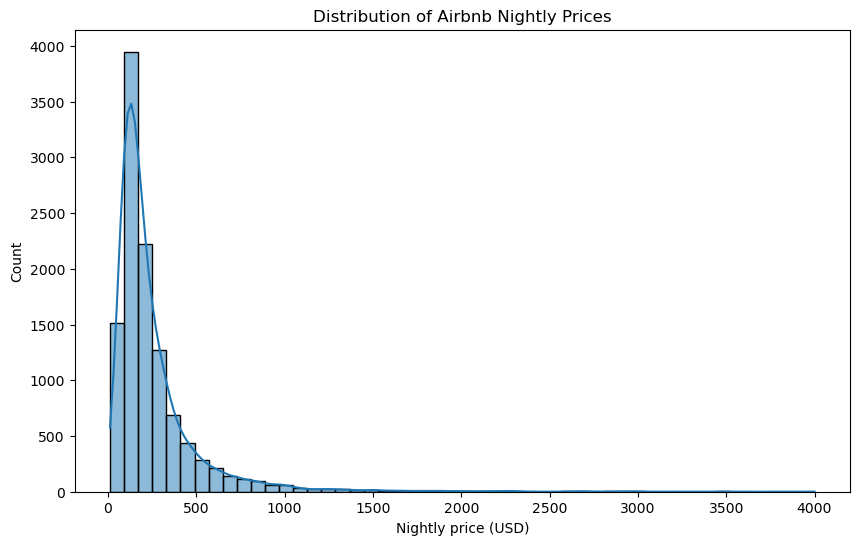

In [17]:
import pandas as pd

df = pd.read_csv("data/02-processed/listings_clean.csv")

df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

print(df.columns.tolist())

# Plot distribution of nightly_price
plt.figure(figsize=(10,6))
sns.histplot(df['nightly_price'], bins=50, kde=True)
plt.title("Distribution of Airbnb Nightly Prices")
plt.xlabel("Nightly price (USD)")
plt.ylabel("Count")
plt.show()

#### Section 2: Relationship Between Price and Property Features

Next, we examine how nightly prices vary across different property characteristics, focusing on `property_type` and `room_type`. These categorical variables capture structural differences between listings (e.g., entire home vs. private room, apartment vs. house), which are expected to have strong economic implications for pricing.

Specifically, we analyze:

- Differences in median and mean prices across categories
- The variability of prices within each category
- Whether certain property types exhibit systematically higher price levels
- The presence of price dispersion within similar listing types

Understanding these relationships helps identify key drivers of pricing and informs feature selection for subsequent modeling. If substantial price differences exist across categories, these variables are likely to be strong predictors in regression or machine learning models.

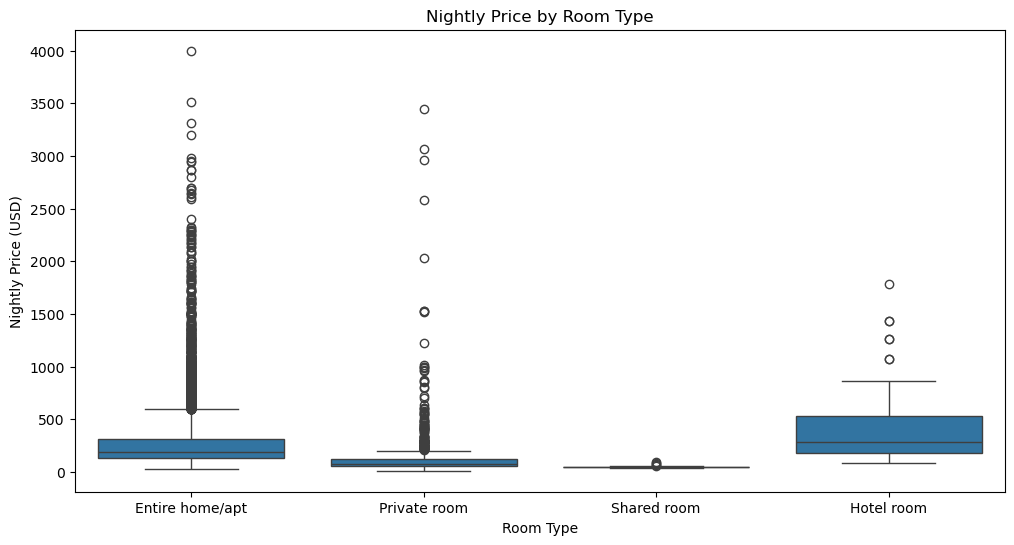

In [18]:
plt.figure(figsize=(12,6))
sns.boxplot(
    x='room_type',
    y='nightly_price',
    data=df
)
plt.title("Nightly Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Nightly Price (USD)")
plt.show()

## Results

### Exploratory Data Analysis

Instructions: replace the words in this subsection with whatever words you need to setup and preview the EDA you're going to do.   

Please explicitly load the fully wrangled data you will use from `data/02-processed`.  This is a good idea rather than forcing people to re-run the data getting / wrangling cells above.  Sometimes it takes a long time to get / wrangle data compared to reloading the fixed up dataset.

Carry out whatever EDA you need to for your project in the code cells below.  Because every project will be different we can't really give you much of a template at this point. But please make sure you describe the what and why in text here as well as providing interpretation of results and context.

Please note that you should consider the use of python modules in your work.  Any code which gets called repeatedly should be modularized. So if you run the same pre-processing, analysis or visualiazation on different subsets of the data, then you should turn that into a function or class.  Put that function or class in a .py file that lives in `modules/`.  Import the module you made and use it to get your work done.  For reference see `get_raw()` which is inside `modules/get_data.py`. 


### Distribution of Nightly Prices

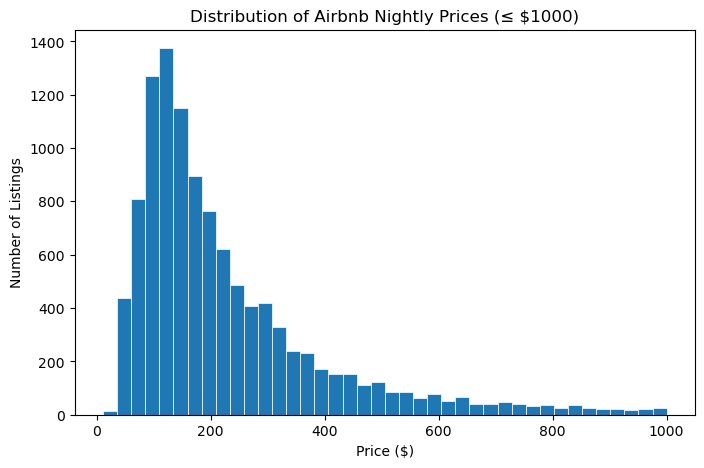

In [19]:
import matplotlib.pyplot as plt

price_num = (
    listings['price']
    .replace('[\$,]', '', regex=True)
    .astype(float)
)

price_filtered = price_num[price_num <= 1000]

plt.figure(figsize=(8,5))
plt.hist(price_filtered, bins=40, edgecolor='white', linewidth=0.5)

plt.title("Distribution of Airbnb Nightly Prices (≤ $1000)")
plt.xlabel("Price ($)")
plt.ylabel("Number of Listings")

plt.show()

The histogram shows the distribution of Airbnb nightly prices after removing extreme outliers above $1000. 

The distribution is right-skewed, indicating that most listings are relatively affordable while only a small number have very high prices. 

Most listings fall between $80 and $250 per night, suggesting that the typical Airbnb price in this dataset lies within this range.

###  Distribution of Room Type

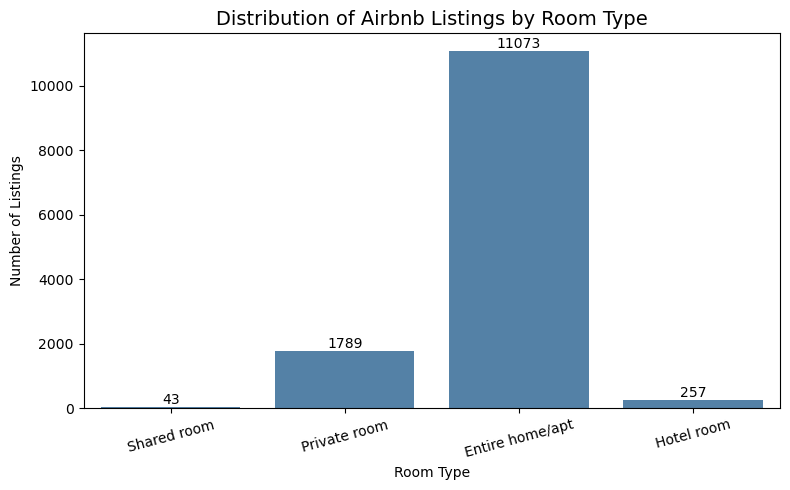

In [34]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=listings,
    x='room_type',
    order=['Shared room','Private room','Entire home/apt','Hotel room'],
    color='steelblue'
)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title("Distribution of Airbnb Listings by Room Type", fontsize=14)
plt.xlabel("Room Type")
plt.ylabel("Number of Listings")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

Most Airbnb listings are entire homes/apartments, while shared and hotel rooms represent only a small portion of the dataset.

### Nightly Price vs. Room Type

In [24]:
price_num = (
    listings['price']
    .replace('[\$,]', '', regex=True)
    .astype(float)
)

listings['price_num'] = price_num

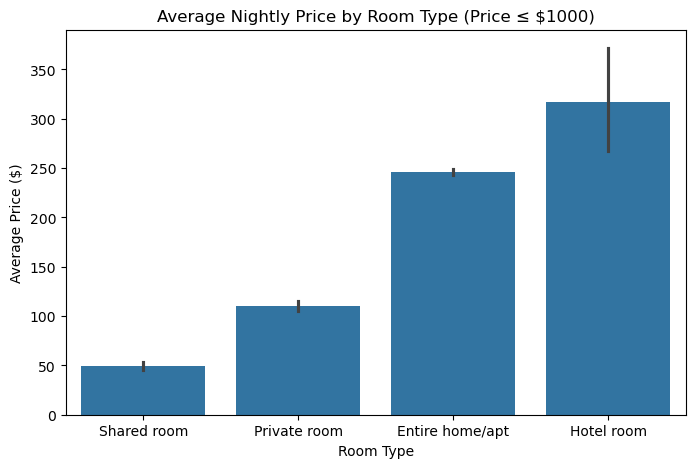

In [27]:
price_num = (
    listings['price']
    .replace('[\$,]', '', regex=True)
    .astype(float)
)

listings['price_num'] = price_num

# 过滤极端价格
filtered = listings[listings['price_num'] <= 1000]

plt.figure(figsize=(8,5))

sns.barplot(
    data=filtered,
    x='room_type',
    y='price_num',
    order=['Shared room','Private room','Entire home/apt','Hotel room']
)

plt.title("Average Nightly Price by Room Type (Price ≤ $1000)")
plt.xlabel("Room Type")
plt.ylabel("Average Price ($)")

plt.show()

From the bar plot, we observe that hotel rooms and entire homes/apartments have the highest average prices, while private rooms are significantly cheaper and shared rooms have the lowest average price. This suggests that listings offering more space and privacy tend to be more expensive.


<Axes: xlabel='room_type', ylabel='price_num'>

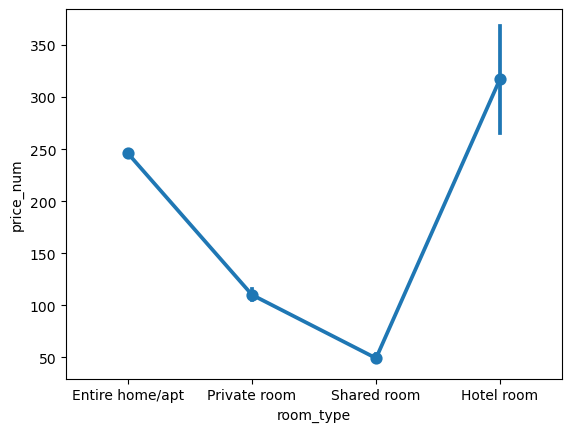

In [28]:
sns.pointplot(
    data=filtered,
    x='room_type',
    y='price_num'
)

The point plot shows the same trend using a connected line to highlight the differences between room types. The clear upward trend from shared rooms to hotel rooms indicates that price generally increases as the level of privacy and accommodation quality improves.

###  Nightly Price vs Minimum Nights

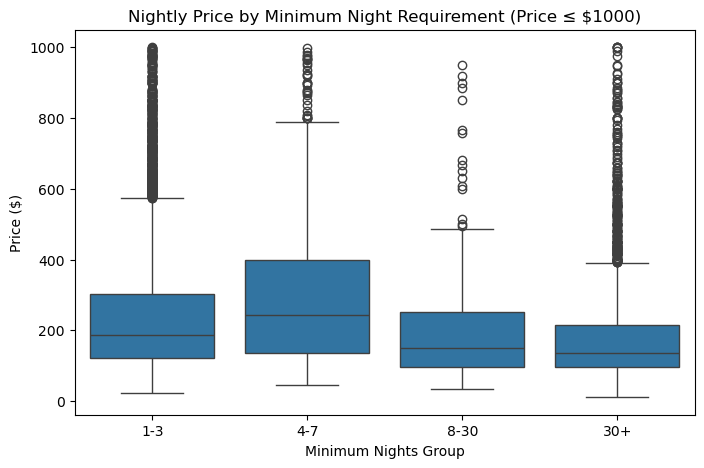

In [29]:
# limit extreme prices
filtered_price = filtered[filtered['price_num'] <= 1000]

# create minimum night groups
filtered_price.loc[:, 'night_group'] = pd.cut(
    filtered_price['minimum_nights'],
    bins=[0,3,7,30,365],
    labels=['1-3','4-7','8-30','30+']
)

plt.figure(figsize=(8,5))

sns.boxplot(
    x='night_group',
    y='price_num',
    data=filtered_price
)

plt.title("Nightly Price by Minimum Night Requirement (Price ≤ $1000)")
plt.xlabel("Minimum Nights Group")
plt.ylabel("Price ($)")
plt.show()

This boxplot shows the distribution of nightly Airbnb prices across different minimum night requirement groups. Listings with a minimum stay of 4–7 nights tend to have slightly higher median prices, while listings requiring longer stays (8–30 or 30+ nights) generally show somewhat lower prices. Overall, the differences across groups are not very large, suggesting that minimum night requirements have only a moderate effect on nightly price.

###  Price Vs Number of Reviews

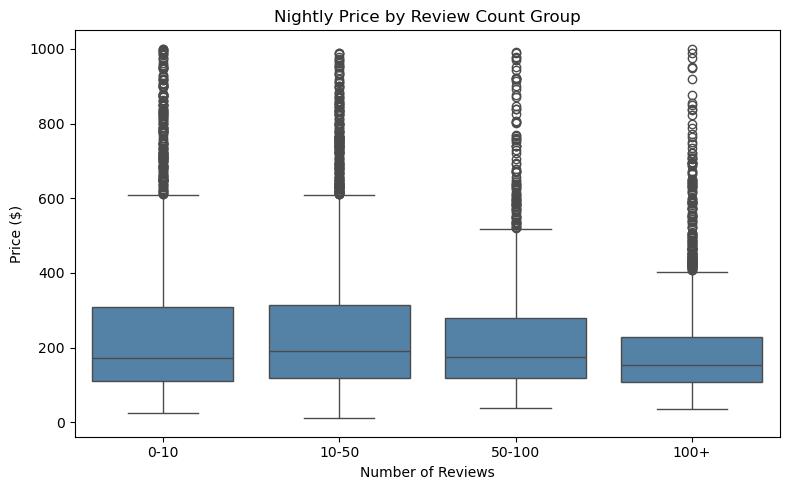

In [38]:
filtered = listings[listings['price_num'] <= 1000].copy()
filtered['review_group'] = pd.cut(
    filtered['number_of_reviews'],
    bins=[0,10,50,100,2000],
    labels=['0-10','10-50','50-100','100+']
)

plt.figure(figsize=(8,5))

sns.boxplot(
    data=filtered,
    x='review_group',
    y='price_num',
    color='steelblue'
)

plt.title("Nightly Price by Review Count Group")
plt.xlabel("Number of Reviews")
plt.ylabel("Price ($)")

plt.tight_layout()
plt.show()

Listings with many reviews may reflect more established or competitively priced listings, which could explain the slightly narrower price distribution.

## Ethics


Our ethics discussion from the proposal stage remains relevant, and we extend it here with observations grounded in the actual data we have wrangled and explored.

### Data collection and representation bias

The Inside Airbnb dataset captures only listings that were *active and publicly visible* on Airbnb at the time of scraping. This creates a systematic **survivorship bias**: listings that have been deactivated, suspended, or voluntarily removed are not present in our data. Hosts who have exited the platform — potentially due to low demand, poor reviews, or local regulation — are invisible to our analysis. Our findings therefore describe the characteristics of *currently active* listings, not the full universe of San Diego short-term rentals.

Additionally, the geographic distribution of listings in our dataset is uneven. Coastal neighborhoods (La Jolla, Pacific Beach, Mission Beach, Coronado) are heavily represented, while inland and lower-income neighborhoods have comparatively fewer listings. This means our model's performance and interpretations may generalize less well to underrepresented areas of the city.

### Neighbourhood as a proxy variable

One of our core predictors — neighbourhood or ZIP code — is a geographic variable that, in the context of San Diego, carries substantial demographic and socioeconomic meaning. Neighbourhoods in San Diego correlate with race and income due to historical patterns of residential segregation and redlining. When our model uses neighbourhood as a predictor of price, it is not capturing "location" in a purely physical sense; it is also encoding information about the social composition of the area.

We do not claim that our model discriminates by race or income — we have no such variables in our dataset. But we acknowledge that neighbourhood-based price predictions could, in practice, function as proxies for protected attributes. Any downstream use of our model (e.g., to guide pricing decisions) should account for this limitation explicitly.

### Review score bias

Our EDA includes review scores as a predictor variable. Review scores are generated only by guests who have booked and chosen to leave a review, which is a non-random subset of all guests. Guests who had very negative experiences may be less likely to write a review (preferring to simply not return), or conversely, more likely to write a negative one. This uncertainty means that review scores are not a neutral measure of quality — they reflect the opinions of a self-selected subset of guests, mediated by price expectations.

### Platform-level bias

Airbnb's search algorithm, pricing suggestions, and promotional features are not neutral. Listings that appear higher in search results may command higher prices not because of their intrinsic characteristics, but because of platform-mediated visibility advantages. Our dataset does not include information about listing visibility or algorithmic promotion, so we cannot account for this source of variation. Our findings should be understood as describing associations within the platform-visible listing pool, not as capturing the full causal structure of Airbnb pricing.

### Honest representation and scope of conclusions

Throughout our EDA and modeling, we commit to representing our findings honestly. Specifically:

- We do not make causal claims. All associations reported are correlational, derived from observational cross-sectional data.
- We acknowledge that our cleaned dataset excludes extreme outliers, which means our model may not generalize well to very high-end luxury listings or unusually cheap listings.
- We use median rather than mean prices where distributions are skewed, to avoid misleading readers about typical price levels.
- Our results describe pricing patterns on the Airbnb platform in San Diego as of the data collection date. They do not represent the full short-term or long-term rental market.
```



## Team Expectations 

The team expectations established in the proposal remain in effect with specific enhancements to support our workflow-based (rather than module-based) EDA approach.

Communication: Our primary mode of communication remains WeChat for daily updates and Zoom/In-person for weekly syncs. We expect all members to respond within 24 hours. During the EDA phase, "tagging" the next person in the workflow (e.g., Qifeng tagging Alina once data is cleaned) is required to maintain momentum.

Tone & Culture: We continue our "blunt but polite" feedback loop. Given that one person's analysis (e.g., visualization) will now be interpreted by another (e.g., narrative), we commit to open dialogue regarding how data is presented to ensure the "story" told in the text accurately reflects the "data" shown in the plots.

Decision Making: Major project decisions (e.g., dropping a variable, changing a model) require a majority vote. For EDA, the Project Lead (Jing) has final say on the overall narrative structure to ensure rubric alignment.

Task Assignment & Accountability: Tasks are assigned by EDA workflow stages (Wrangling -> Visualization -> Statistical Analysis -> Interpretation) and tracked via GitHub Issues. We have transitioned to this model to prevent unequal workload and ensure "Excellent" ratings for team participation. If a member cannot meet a deadline, they must notify the group 48 hours in advance.

Collaboration Structure (New): We explicitly agree that "the person who codes is not the sole person who writes." For every EDA section, the lead analyst must sync with the interpretation lead (Alina) to ensure the narrative provides the depth required by the COGS 108 rubric.

Conflict Resolution: We assume positive intent and use private "neutral ground" discussions for conflicts. Consistent failure to meet expectations will lead to written notice and, if unresolved after one week, contact with the instructor.

## Project Timeline Proposal

Instructions: Replace this with your timeline.  **PLEASE UPDATE your Timeline!** No battle plan survives contact with the enemy, so make sure we understand how your plans have changed.  Also if you have lost points on the previous checkpoint fix them
| Meeting Date  | Meeting Time| Completed Before Meeting  | Discuss at Meeting |
|---|---|---|---|
| week2-Jan15  |  1 PM | Everyone:Read & Think about COGS 108 expectations; brainstorm topics/questions <br> Jing: Draft initial project topic and research question.| Determine best form of communication; Discuss and decide on final project topic; discuss hypothesis; begin background research | 
| week3-Jan22  |  10 AM |  Everyone: Do background research on topic <br>Jing: Draft Background & Prior Work (2-3 paragraphs). <br>Qifeng: Describe ideal Data (variables like price, location, room type). <br>Alina: Draft Ethics & Privacy + Team Expectations. | Discuss ideal dataset(s) and ethics; draft project proposal; Assign group members to lead each specific part | 
| week5-Feb3  | 10 PM  | Everyone: Edit, finalize, Final proofreading and submit proposal; Search for datasets<br>Yuqian: Write Analysis Plan (Regression/EDA focus).<br>Jing: Merge all sections into the final notebook; Check against rubric. | Submit Proposal. Discuss specific data acquisition strategy for San Diego Airbnb (Inside Airbnb/Kaggle). Wrangling and possible analytical approaches;   |
| week6-Feb11  | 6 PM  | Qifeng: Download and document the SD Airbnb dataset.<br>Ivy: Perform initial Data Cleaning (handling missing prices, filtering SD coordinates).<br>Yuqian: Preliminary EDA on price distribution. | Review Wrangling/EDA: Discuss if we need more features (e.g., amenities, proximity to coast) to test the hypothesis.   |
| week7-Feb18  | 12 PM  | Ivy: Finalize EDA visualizations (Price vs. Location heatmaps).<br>Yuqian: Run initial Regression Models (Price ~ Distance to coast + Room type).<br>Jing: Draft Checkpoint #1 documentation.; submit Checkpoint #1: Data* | Submit Checkpoint #1. Discuss if the model results support the hypothesis that scenic areas = higher prices. |
| week8-Feb28  | 2 PM | Alina: Prepare draft for data bias & ethics interpretation. <br>Yuqian: Complete bivariate analysis (Price vs. Features). | Alina & Yuqian Meeting: Discuss EDA logic flow; align statistical findings with contextual interpretation; identify any bias in the processed data. |
| week9-Mar3  | 12 PM  | Yuqian: Finalize Modeling & Interpretation of results.<br>Alina: Write Discussion (limitations of observational data) & Conclusion.<br>Ivy: Optimize all charts for clarity.<br>Jing: Compile the full project notebook.| Full Project Review: Edit the narrative flow; Ensure ethics/limitations are thoroughly addressed. Submit Checkpoint #2. |
| week10-Mar11  | Before 11:59 PM  | Alina: Finalize Video script & narration coordination.<br>Jing: Final check on all rubric requirements and formatting.<br>Everyone: Complete peer evaluation surveys. | Final Submission: Turn in the Final Project, Video, and Group Surveys. |